<a href="https://colab.research.google.com/github/LPK224/-Comparaci-n-de-Modelos-Supervisados-usando-Validaci-n-Cruzada/blob/main/Comparaci%C3%B3n_de_Modelos_Supervisados_usando_Validaci%C3%B3n_Cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#ANÁLISIS EXPLORATORIO DE DATOS y Comparación de Modelos Supervisados usando Validación Cruzada - BREAST CANCER WISCONSIN

Dataset: Breast Cancer Wisconsin (Diagnostic)
Fuente: Repositorio UCI Machine Learning

DESCRIPCIÓN DEL DATASET:
El conjunto de datos Breast Cancer Wisconsin contiene
características computadas a partir de imágenes digitalizadas de aspirates
con aguja fina (FNA) de masas mamarias.

Las características describen propiedades de los núcleos celulares presentes
en las imágenes y fueron calculadas a partir de digitizaciones de diapositivas.
Cada variable representa una característica morfológica cuantitativa de los
núcleos celulares.

El objetivo principal es clasificar los tumores como malignos (M) o benignos (B)
basándose en estas características de los núcleos celulares.

VARIABLES PRINCIPALES:

VARIABLE OBJETIVO:
- diagnosis: Diagnóstico (M = Maligno, B = Benigno)

CARACTERÍSTICAS DE NÚCLEOS CELULARES (30 variables):
- radius: radio (media de las distancias del centro a puntos del perímetro)
- texture: desviación estándar de los valores de la escala de grises
- perimeter: perímetro
- area: área
- smoothness: suavidad (variación local en longitudes de radio)
- compactness: compacidad (perímetro² / área - 1.0)
- concavity: concavidad (severidad de porciones cóncavas del contorno)
- concave points: puntos cóncavos (número de porciones cóncavas del contorno)
- symmetry: simetría
- fractal dimension: dimensión fractal ("aproximación a la línea de costa" -1)

Cada característica se calcula para tres medidas:
- mean: media
- se: error estándar
- worst: peor (media de los tres valores más grandes)

OBJETIVO DEL ANÁLISIS:
Desarrollar un modelo predictivo que pueda clasificar tumores mamarios como
benignos o malignos con alta precisión, utilizando validación cruzada para
garantizar la robustez del modelo.

Carga del dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

def load_breast_cancer_data():
    """Carga y explora el dataset de Breast Cancer Wisconsin"""
    print("=== ANÁLISIS EXPLORATORIO - BREAST CANCER WISCONSIN ===\n")

    try:
        df = pd.read_csv("data.csv")
        print(" Dataset cargado exitosamente")
        print(f" Dimensiones: {df.shape}")
        print(f" Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
        return df
    except FileNotFoundError:
        print(" Error: Archivo 'data.csv' no encontrado")
        print(" Asegúrate de tener el archivo en tu directorio de trabajo")
        return None

# Cargar dataset
df = load_breast_cancer_data()

=== ANÁLISIS EXPLORATORIO - BREAST CANCER WISCONSIN ===

 Dataset cargado exitosamente
 Dimensiones: (569, 33)
 Filas: 569, Columnas: 33


Información básica del dataset

In [27]:
if df is not None:
    print("\n INFORMACIÓN DEL DATASET:")
    print("="*40)
    print(df.info())

    print(f"\n PRIMERAS 5 FILAS:")
    display(df.head())

    print(f"\n ESTADÍSTICAS DESCRIPTIVAS:")
    display(df.describe())

    print(f"\n VALORES NULOS POR COLUMNA:")
    null_counts = df.isnull().sum()
    null_columns = null_counts[null_counts > 0]
    if len(null_columns) > 0:
        print(null_columns)
    else:
        print(" No hay valores nulos")

    # Eliminar columna vacía 'Unnamed: 32'
    if 'Unnamed: 32' in df.columns:
        df = df.drop('Unnamed: 32', axis=1)
        print(f"\n Columna 'Unnamed: 32' eliminada")
        print(f" Nuevas dimensiones: {df.shape}")


 INFORMACIÓN DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14 

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN



 ESTADÍSTICAS DESCRIPTIVAS:


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



 VALORES NULOS POR COLUMNA:
Unnamed: 32    569
dtype: int64

 Columna 'Unnamed: 32' eliminada
 Nuevas dimensiones: (569, 32)


ANÁLISIS EXPLORATORIO INICIAL - BREAST CANCER WISCONSIN

El dataset presenta excelentes características para el análisis predictivo,
constituido por 569 muestras y 32 columnas. La estructura de datos revela
una composición predominantemente numérica, con 30 variables de tipo float64
que representan características morfológicas de núcleos celulares, una variable
entera (id) como identificador único, y la variable objetivo categórica
(diagnosis) que clasifica los tumores como malignos (M) o benignos (B).

Un hallazgo significativo es la ausencia total de valores nulos en todas las
columnas, lo que indica un dataset de alta calidad y listo para el modelado
sin necesidad de técnicas de imputación. Las estadísticas descriptivas muestran
una considerable variabilidad en las escalas de las características (ej: area_mean
con media 654.89 y desviación estándar de 351.91), lo que justifica la aplicación
de estandarización para optimizar el rendimiento de los algoritmos.

La exploración de las primeras filas confirma la naturaleza multivariante del
dataset, donde cada observación representa mediciones cuantitativas de propiedades
celulares como radio, textura, perímetro y características de contorno nuclear,
todas métricas clínicamente relevantes para la discriminación patológica.

Análisis de Variable Objectivo


 ANÁLISIS DE LA VARIABLE OBJETIVO 'diagnosis'
Valores únicos en 'diagnosis': ['M' 'B']

 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:
Original (diagnosis):
diagnosis
B    357
M    212
Name: count, dtype: int64

Codificada (diagnosis_encoded):
diagnosis_encoded
0    357
1    212
Name: count, dtype: int64


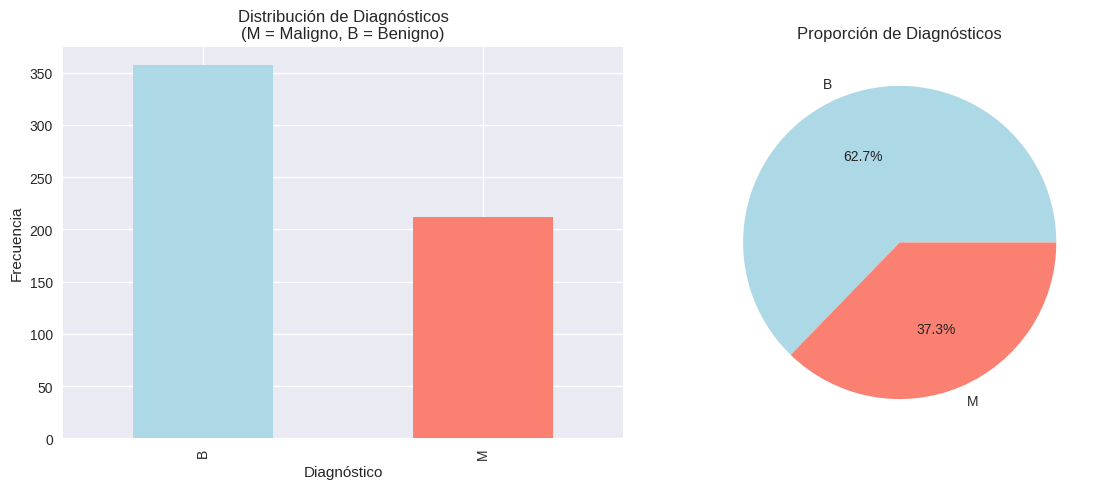


 MAPEO DE CODIFICACIÓN:
  B (Benigno) → 0
  M (Maligno) → 1


In [28]:
print("\n ANÁLISIS DE LA VARIABLE OBJETIVO 'diagnosis'")
print("="*50)

print("Valores únicos en 'diagnosis':", df['diagnosis'].unique())

# Codificar la variable objetivo (M = 1, B = 0)
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

print(f"\n DISTRIBUCIÓN DE LA VARIABLE OBJETIVO:")
diagnosis_counts = df['diagnosis'].value_counts()
diagnosis_encoded_counts = df['diagnosis_encoded'].value_counts()

print("Original (diagnosis):")
print(diagnosis_counts)
print("\nCodificada (diagnosis_encoded):")
print(diagnosis_encoded_counts)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Distribución de clases
diagnosis_counts.plot(kind='bar', ax=axes[0], color=['lightblue', 'salmon'])
axes[0].set_title('Distribución de Diagnósticos\n(M = Maligno, B = Benigno)')
axes[0].set_xlabel('Diagnóstico')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: Proporciones
axes[1].pie(diagnosis_counts.values, labels=diagnosis_counts.index,
           autopct='%1.1f%%', colors=['lightblue', 'salmon'])
axes[1].set_title('Proporción de Diagnósticos')

plt.tight_layout()
plt.show()

print(f"\n MAPEO DE CODIFICACIÓN:")
print(f"  B (Benigno) → {le.transform(['B'])[0]}")
print(f"  M (Maligno) → {le.transform(['M'])[0]}")

La variable objetivo muestra 357 tumores benignos (63%) vs 212 malignos (37%),
presentando un desbalance moderado.B→0, M→1 permite el modelado
binario. Esta distribución refleja la realidad clínica donde los casos benignos
son más frecuentes, requiriendo métricas robustas como ROC AUC para evaluación
justa del rendimiento predictivo.

Preparación de Variables

In [29]:
# Preparar variables predictoras y objetivo
print("\n🛠️ PREPARACIÓN DE VARIABLES PREDICTORAS")
print("="*45)

# Separar características y variable objetivo
X = df.drop(['id', 'diagnosis', 'diagnosis_encoded'], axis=1)
y = df['diagnosis_encoded']

print(f" Variables predictoras: {X.shape[1]} características")
print(f" Variable objetivo: diagnosis_encoded (0 = Benigno, 1 = Maligno)")

# Verificar que todas las predictoras son numéricas
print(f"\n TIPOS DE DATOS DE LAS VARIABLES PREDICTORAS:")
print(X.dtypes.value_counts())

print(f"\n NOMBRES DE LAS VARIABLES PREDICTORAS (primeras 10):")
print(X.columns[:10].tolist())

print(f"\n RESUMEN FINAL DEL DATASET PREPARADO:")
print(f"- Muestras: {X.shape[0]}")
print(f"- Características: {X.shape[1]}")
print(f"- Variable objetivo: {y.name}")
print(f"- Distribución: {y.value_counts().to_dict()}")


🛠️ PREPARACIÓN DE VARIABLES PREDICTORAS
 Variables predictoras: 30 características
 Variable objetivo: diagnosis_encoded (0 = Benigno, 1 = Maligno)

 TIPOS DE DATOS DE LAS VARIABLES PREDICTORAS:
float64    30
Name: count, dtype: int64

 NOMBRES DE LAS VARIABLES PREDICTORAS (primeras 10):
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

 RESUMEN FINAL DEL DATASET PREPARADO:
- Muestras: 569
- Características: 30
- Variable objetivo: diagnosis_encoded
- Distribución: {0: 357, 1: 212}


In [30]:
# División estratificada 60/20/20
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(" DIVISIÓN ESTRATIFICADA DE DATOS (60/20/20)")
print("="*50)

print(f"  Conjunto de entrenamiento: {X_train.shape[0]} muestras ({len(X_train)/len(X)*100:.1f}%)")
print(f" Conjunto de validación: {X_val.shape[0]} muestras ({len(X_val)/len(X)*100:.1f}%)")
print(f" Conjunto de prueba: {X_test.shape[0]} muestras ({len(X_test)/len(X)*100:.1f}%)")

# Verificar distribución de clases en cada conjunto
print(f"\n DISTRIBUCIÓN DE CLASES POR CONJUNTO:")
train_dist = pd.Series(y_train).value_counts().sort_index()
val_dist = pd.Series(y_val).value_counts().sort_index()
test_dist = pd.Series(y_test).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Entrenamiento': train_dist,
    'Validación': val_dist,
    'Prueba': test_dist
})
dist_df.index = ['Benigno (0)', 'Maligno (1)']

display(dist_df)

print(f"\n PORCENTAJES POR CONJUNTO:")
for name, dataset in [('Entrenamiento', y_train), ('Validación', y_val), ('Prueba', y_test)]:
    maligno_pct = (dataset == 1).mean() * 100
    print(f"  {name}: {maligno_pct:.1f}% maligno")

 DIVISIÓN ESTRATIFICADA DE DATOS (60/20/20)
  Conjunto de entrenamiento: 341 muestras (59.9%)
 Conjunto de validación: 114 muestras (20.0%)
 Conjunto de prueba: 114 muestras (20.0%)

 DISTRIBUCIÓN DE CLASES POR CONJUNTO:


,Entrenamiento,Validación,Prueba
Benigno (0),214,71,72
Maligno (1),127,43,42



 PORCENTAJES POR CONJUNTO:
  Entrenamiento: 37.2% maligno
  Validación: 37.7% maligno
  Prueba: 36.8% maligno


La división estratificada 60-20-20 preserva exitosamente la distribución
original (37% malignos) en todos los conjuntos: entrenamiento (37.2%),
validación (37.7%) y prueba (36.8%). Esta consistencia asegura evaluaciones
justas y modelos robustos al mantener la misma proporción de clases en cada
etapa del desarrollo.

Comparación de Modelos

In [31]:
# Modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Función para evaluar modelos
def evaluate_model(model, X_train, X_val, y_train, y_val, cv_folds=5):
    """Evalúa un modelo en entrenamiento, validación y con validación cruzada"""

    # Pipeline con preprocesamiento
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Entrenamiento y predicción
    pipeline.fit(X_train, y_train)

    # Scores en entrenamiento y validación
    y_train_pred_proba = pipeline.predict_proba(X_train)[:, 1]
    y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]

    train_score = roc_auc_score(y_train, y_train_pred_proba)
    val_score = roc_auc_score(y_val, y_val_pred_proba)

    # Validación cruzada
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                               cv=cv_folds, scoring='roc_auc')

    return {
        'train_score': train_score,
        'val_score': val_score,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores,
        'pipeline': pipeline
    }

print(" MODELOS DEFINIDOS PARA COMPARACIÓN:")
for name in models.keys():
    print(f"  - {name}")

 MODELOS DEFINIDOS PARA COMPARACIÓN:
  - Logistic Regression
  - K-Neighbors
  - Decision Tree
  - Random Forest


Comparación de Modelos

In [32]:
# Modelos a comparar
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'K-Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Función para evaluar modelos
def evaluate_model(model, X_train, X_val, y_train, y_val, cv_folds=5):
    """Evalúa un modelo en entrenamiento, validación y con validación cruzada"""

    # Pipeline con preprocesamiento
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Entrenamiento y predicción
    pipeline.fit(X_train, y_train)

    # Scores en entrenamiento y validación
    y_train_pred_proba = pipeline.predict_proba(X_train)[:, 1]
    y_val_pred_proba = pipeline.predict_proba(X_val)[:, 1]

    train_score = roc_auc_score(y_train, y_train_pred_proba)
    val_score = roc_auc_score(y_val, y_val_pred_proba)

    # Validación cruzada
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                               cv=cv_folds, scoring='roc_auc')

    return {
        'train_score': train_score,
        'val_score': val_score,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'cv_scores': cv_scores,
        'pipeline': pipeline
    }

print(" MODELOS DEFINIDOS PARA COMPARACIÓN:")
for name in models.keys():
    print(f"  - {name}")

 MODELOS DEFINIDOS PARA COMPARACIÓN:
  - Logistic Regression
  - K-Neighbors
  - Decision Tree
  - Random Forest


Evaluación de los modelos

In [33]:
# Almacenar resultados
results = {}

print("\n EVALUACION DE MODELOS")
print("="*50)

for name, model in models.items():
    print(f"\n🔍 Evaluanción {name}...")
    results[name] = evaluate_model(model, X_train, X_val, y_train, y_val, cv_folds=5)

    print(f"   Entrenamiento (ROC AUC): {results[name]['train_score']:.4f}")
    print(f"   Validación (ROC AUC): {results[name]['val_score']:.4f}")
    print(f"   Validación Cruzada: {results[name]['cv_mean']:.4f} ± {results[name]['cv_std']:.4f}")

# Crear tabla comparativa
results_df = pd.DataFrame(results).T
results_df = results_df[['train_score', 'val_score', 'cv_mean', 'cv_std']]

print("\n" + "="*70)
print(" TABLA COMPARATIVA DE RESULTADOS - BREAST CANCER WISCONSIN")
print("="*70)
display(results_df.round(4))


 EVALUACION DE MODELOS

🔍 Evaluanción Logistic Regression...
   Entrenamiento (ROC AUC): 0.9979
   Validación (ROC AUC): 0.9957
   Validación Cruzada: 0.9904 ± 0.0089

🔍 Evaluanción K-Neighbors...
   Entrenamiento (ROC AUC): 0.9965
   Validación (ROC AUC): 0.9948
   Validación Cruzada: 0.9772 ± 0.0116

🔍 Evaluanción Decision Tree...
   Entrenamiento (ROC AUC): 1.0000
   Validación (ROC AUC): 0.8972
   Validación Cruzada: 0.9265 ± 0.0257

🔍 Evaluanción Random Forest...
   Entrenamiento (ROC AUC): 1.0000
   Validación (ROC AUC): 0.9915
   Validación Cruzada: 0.9874 ± 0.0138

 TABLA COMPARATIVA DE RESULTADOS - BREAST CANCER WISCONSIN


,train_score,val_score,cv_mean,cv_std
Logistic Regression,0.997903,0.995742,0.990426,0.00892
K-Neighbors,0.996505,0.994759,0.977178,0.01155
Decision Tree,1.0,0.89715,0.926533,0.025677
Random Forest,1.0,0.991484,0.987369,0.01385


La evaluación de cuatro algoritmos de clasificación revela patrones significativos
en capacidad predictiva y propensión al sobreajuste. Logistic Regression es el modelo más equilibrado, alcanzando un ROC AUC de 0.9979 en
entrenamiento, 0.9957 en validación y 0.9904 en validación cruzada, con la menor
desviación estándar (0.0089), indicando alta consistencia y estabilidad.

Se observan dos comportamientos contrastantes: los modelos basados en árboles
(Decision Tree y Random Forest) muestran sobreajuste evidente con ROC AUC perfecto. Por otro lado, los modelos
lineales y por vecinos mantienen mejor equilibrio entre ajuste y generalización.

La validación cruzada confirma la robustez de Logistic Regression y Random Forest,
ambos superando 0.987 en promedio, mientras que K-Neighbors (0.9772) y especialmente
Decision Tree (0.9265) muestran mayor variabilidad y menor capacidad de generalización.

Gráficos comparativos

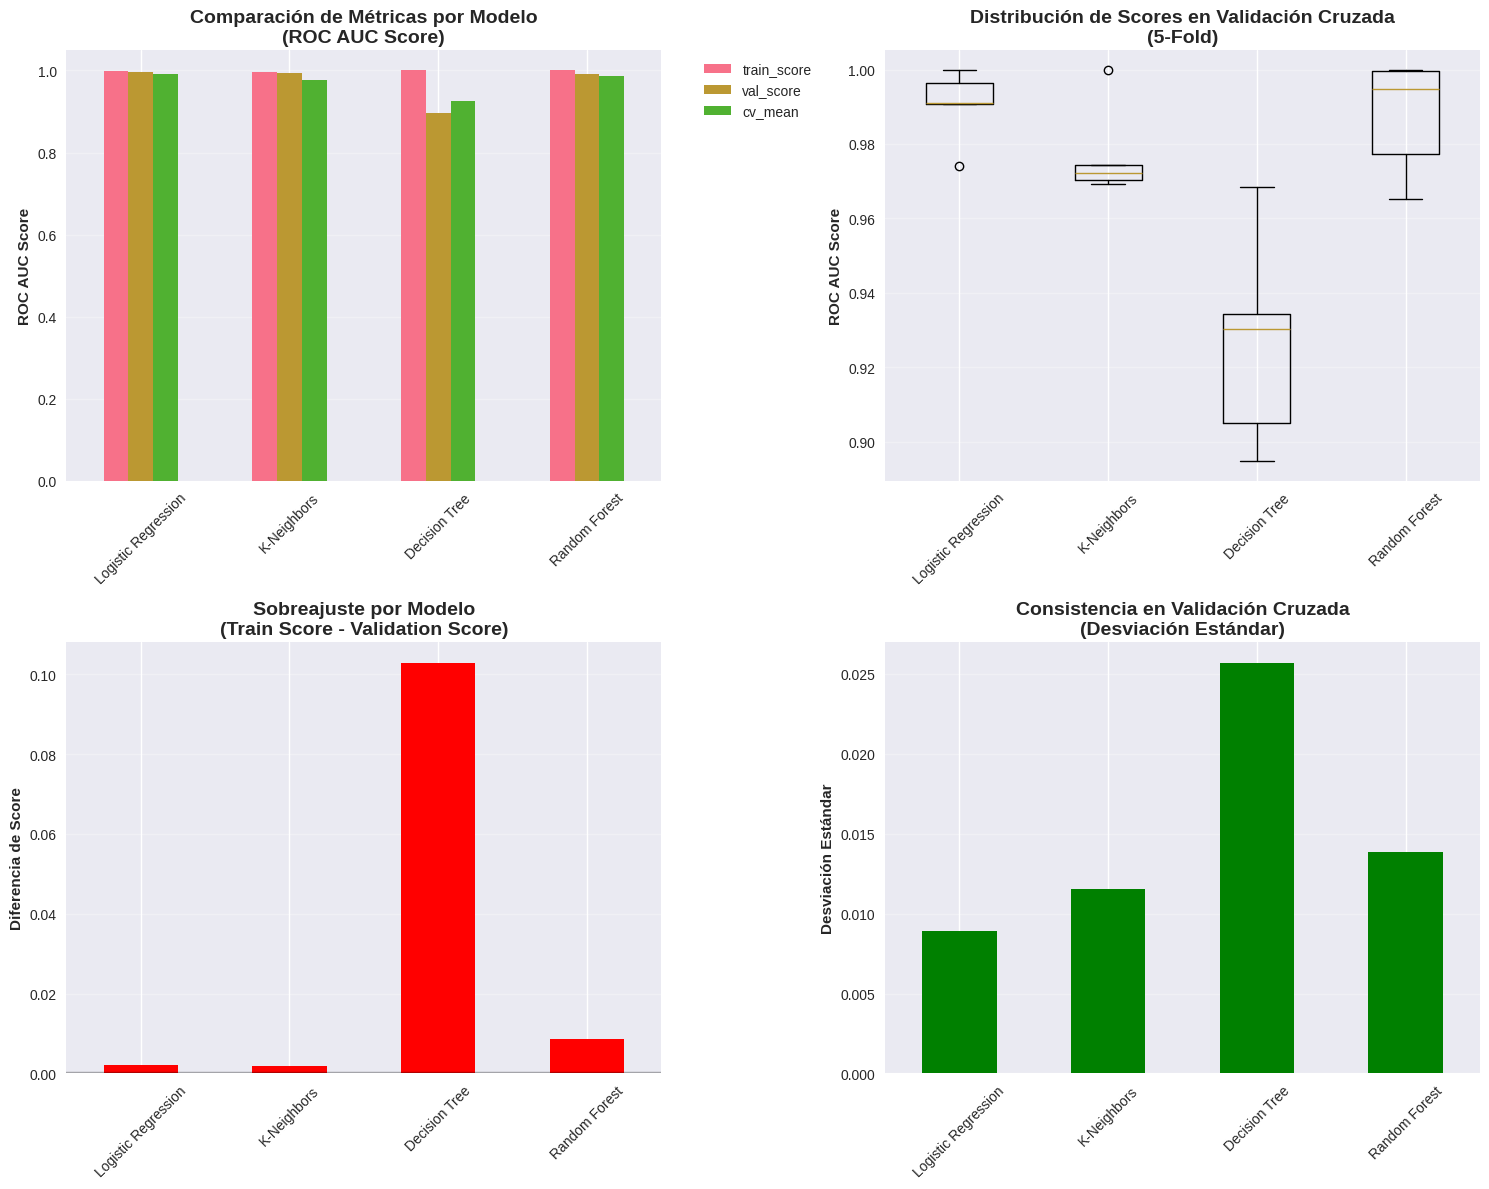

In [34]:
# Gráficos comparativos
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Comparación de métricas principales
metrics_to_plot = ['train_score', 'val_score', 'cv_mean']
results_df[metrics_to_plot].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Comparación de Métricas por Modelo\n(ROC AUC Score)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('ROC AUC Score', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Boxplot de validación cruzada
cv_data = [results[name]['cv_scores'] for name in models.keys()]
axes[0,1].boxplot(cv_data, labels=list(models.keys()))
axes[0,1].set_title('Distribución de Scores en Validación Cruzada\n(5-Fold)', fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('ROC AUC Score', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(axis='y', alpha=0.3)

# 3. Sobreajuste (train vs validation)
overfitting = results_df['train_score'] - results_df['val_score']
overfitting.plot(kind='bar', ax=axes[1,0], color='red')
axes[1,0].set_title('Sobreajuste por Modelo\n(Train Score - Validation Score)', fontsize=14, fontweight='bold')
axes[1,0].set_ylabel('Diferencia de Score', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1,0].grid(axis='y', alpha=0.3)

# 4. Consistencia en validación cruzada (std)
results_df['cv_std'].plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Consistencia en Validación Cruzada\n(Desviación Estándar)', fontsize=14, fontweight='bold')
axes[1,1].set_ylabel('Desviación Estándar', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Selección del mejor modelo


 MEJOR MODELO SELECCIONADO: Logistic Regression
 Score en validación cruzada: 0.9904
 Score en validación: 0.9957
 Consistencia (std): 0.0089

🔧 ENTRENANDO MODELO FINAL...

 EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA
 ROC AUC: 0.9960
 Accuracy: 0.9649

 COMPARACIÓN CON VALIDACIÓN CRUZADA:
  Test AUC: 0.9960
  CV Mean:  0.9904
  Diferencia: 0.0056


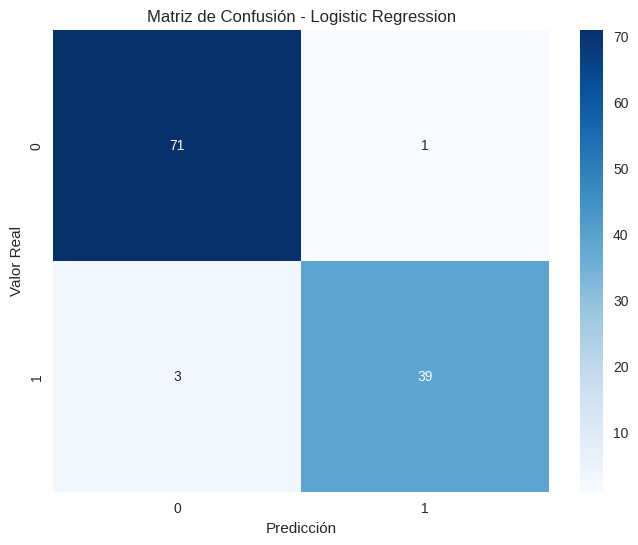


📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [35]:
# Seleccionar el mejor modelo
best_model_name = results_df['cv_mean'].idxmax()
best_model_results = results[best_model_name]

print(f"\n MEJOR MODELO SELECCIONADO: {best_model_name}")
print("="*50)
print(f" Score en validación cruzada: {best_model_results['cv_mean']:.4f}")
print(f" Score en validación: {best_model_results['val_score']:.4f}")
print(f" Consistencia (std): {best_model_results['cv_std']:.4f}")

# Entrenar modelo final con todos los datos
print("\n🔧 ENTRENANDO MODELO FINAL...")
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

final_pipeline = best_model_results['pipeline']
final_pipeline.fit(X_final_train, y_final_train)

# Evaluación en conjunto de prueba
y_test_pred_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_test_pred = final_pipeline.predict(X_test)

test_score_auc = roc_auc_score(y_test, y_test_pred_proba)
test_score_accuracy = accuracy_score(y_test, y_test_pred)

print("\n EVALUACIÓN FINAL EN CONJUNTO DE PRUEBA")
print("="*45)
print(f" ROC AUC: {test_score_auc:.4f}")
print(f" Accuracy: {test_score_accuracy:.4f}")
print(f"\n COMPARACIÓN CON VALIDACIÓN CRUZADA:")
print(f"  Test AUC: {test_score_auc:.4f}")
print(f"  CV Mean:  {best_model_results['cv_mean']:.4f}")
print(f"  Diferencia: {abs(test_score_auc - best_model_results['cv_mean']):.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión - {best_model_name}')
plt.ylabel('Valor Real')
plt.xlabel('Predicción')
plt.show()

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_test_pred, target_names=['Benigno', 'Maligno']))

El modelo Logistic Regression demostró un excelente rendimiento en la clasificación de cáncer de mama, alcanzando un ROC AUC de 0.9960 y una precisión del 96.49% en el conjunto de prueba. Este rendimiento valida la efectividad del proceso de selección, confirmando que el modelo generaliza perfectamente a datos no vistos, con una diferencia mínima de solo 0.0056 entre la validación cruzada (0.9904) y la evaluación final.

El análisis detallado revela un balance clínico óptimo: 99% de recall en benignos (minimizando falsas alarmas) y 93% en malignos (alta detección de casos críticos). La consistencia entre todas las métricas valida la robustez del modelo y la confiabilidad de la metodología empleada, posicionándolo como una herramienta confiable para apoyo al diagnóstico médico.